In [1]:
import os, random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

print(f"Seeds fixed: {SEED}")

Seeds fixed: 42


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/alzheimer-ai/'

print("PROJECT_ROOT =", PROJECT_ROOT)

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/alzheimer-ai/


In [3]:
!pip install scikit-learn matplotlib seaborn pandas numpy pillow -q

In [4]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, Model, Input

os.makedirs(PROJECT_ROOT + 'weights', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'reports/figures', exist_ok=True)
os.makedirs(PROJECT_ROOT + 'data/processed', exist_ok=True)

print("Imports ready.")

Imports ready.


In [5]:
IMAGE_ARRAY_DIR = PROJECT_ROOT + 'data/processed/image_arrays/'
TABULAR_DIR = PROJECT_ROOT + 'data/processed/tabular/'

required_files = [
    IMAGE_ARRAY_DIR + 'X_train.npy',
    IMAGE_ARRAY_DIR + 'X_val.npy',
    IMAGE_ARRAY_DIR + 'X_test.npy',
    TABULAR_DIR + 'tab_train.npy',
    TABULAR_DIR + 'tab_val.npy',
    TABULAR_DIR + 'tab_test.npy',
    TABULAR_DIR + 'y_train.npy',
    TABULAR_DIR + 'y_val.npy',
    TABULAR_DIR + 'y_test.npy',
    PROJECT_ROOT + 'weights/backbone_resnet50.weights.h5',
    PROJECT_ROOT + 'data/processed/class_weight_dict.pkl',
    PROJECT_ROOT + 'data/processed/baseline_metrics.csv'
]

for f in required_files:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing required file: {f}")

X_train = np.load(IMAGE_ARRAY_DIR + 'X_train.npy').astype(np.float32)
X_val = np.load(IMAGE_ARRAY_DIR + 'X_val.npy').astype(np.float32)
X_test = np.load(IMAGE_ARRAY_DIR + 'X_test.npy').astype(np.float32)

tab_train = np.load(TABULAR_DIR + 'tab_train.npy').astype(np.float32)
tab_val = np.load(TABULAR_DIR + 'tab_val.npy').astype(np.float32)
tab_test = np.load(TABULAR_DIR + 'tab_test.npy').astype(np.float32)

y_train = np.load(TABULAR_DIR + 'y_train.npy').astype(np.int64)
y_val = np.load(TABULAR_DIR + 'y_val.npy').astype(np.int64)
y_test = np.load(TABULAR_DIR + 'y_test.npy').astype(np.int64)

with open(PROJECT_ROOT + 'data/processed/class_weight_dict.pkl', 'rb') as f:
    class_weight_dict = pickle.load(f)

class_weight_dict = {int(k): float(v) for k, v in class_weight_dict.items()}

baseline_metrics_df = pd.read_csv(PROJECT_ROOT + 'data/processed/baseline_metrics.csv')

print("X_train:", X_train.shape)
print("tab_train:", tab_train.shape)
print("y_train:", y_train.shape)

print("Train counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Val counts:", dict(zip(*np.unique(y_val, return_counts=True))))
print("Test counts:", dict(zip(*np.unique(y_test, return_counts=True))))

print("Class weights:", class_weight_dict)
display(baseline_metrics_df)

X_train: (262, 224, 224, 3)
tab_train: (262, 4)
y_train: (262,)
Train counts: {np.int64(0): np.int64(132), np.int64(1): np.int64(27), np.int64(2): np.int64(103)}
Val counts: {np.int64(0): np.int64(27), np.int64(1): np.int64(5), np.int64(2): np.int64(20)}
Test counts: {np.int64(0): np.int64(31), np.int64(1): np.int64(5), np.int64(2): np.int64(23)}
Class weights: {0: 0.6616161616161617, 1: 3.234567901234568, 2: 0.8478964401294499}


,metric,value,target,passed
0,Accuracy,0.542373,0.85,False
1,Recall macro,0.392707,0.88,False
2,F1 macro,0.374236,0.85,False
3,AUC-ROC,0.558608,0.90,False
4,Recall MCI,0.000000,0.85,False
5,Specificity,0.612903,0.82,False


In [6]:
def oversample_minority_classes(X, tab, y, target_count=None, random_state=42):
    rng = np.random.default_rng(random_state)

    classes, counts = np.unique(y, return_counts=True)
    count_dict = dict(zip(classes, counts))

    if target_count is None:
        target_count = max(counts)

    X_parts = []
    tab_parts = []
    y_parts = []

    for cls in classes:
        idx = np.where(y == cls)[0]
        current_count = len(idx)

        if current_count < target_count:
            extra_idx = rng.choice(idx, size=target_count - current_count, replace=True)
            final_idx = np.concatenate([idx, extra_idx])
        else:
            final_idx = idx

        X_parts.append(X[final_idx])
        tab_parts.append(tab[final_idx])
        y_parts.append(y[final_idx])

    X_bal = np.concatenate(X_parts, axis=0)
    tab_bal = np.concatenate(tab_parts, axis=0)
    y_bal = np.concatenate(y_parts, axis=0)

    perm = rng.permutation(len(y_bal))

    return X_bal[perm], tab_bal[perm], y_bal[perm]


X_train_bal, tab_train_bal, y_train_bal = oversample_minority_classes(
    X_train,
    tab_train,
    y_train,
    target_count=max(np.unique(y_train, return_counts=True)[1]),
    random_state=42
)

print("Before oversampling:", dict(zip(*np.unique(y_train, return_counts=True))))
print("After oversampling:", dict(zip(*np.unique(y_train_bal, return_counts=True))))

print("X_train_bal:", X_train_bal.shape)
print("tab_train_bal:", tab_train_bal.shape)
print("y_train_bal:", y_train_bal.shape)

Before oversampling: {np.int64(0): np.int64(132), np.int64(1): np.int64(27), np.int64(2): np.int64(103)}
After oversampling: {np.int64(0): np.int64(132), np.int64(1): np.int64(132), np.int64(2): np.int64(132)}
X_train_bal: (396, 224, 224, 3)
tab_train_bal: (396, 4)
y_train_bal: (396,)


In [7]:
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

rotation_layer = tf.keras.layers.RandomRotation(0.10)
zoom_layer = tf.keras.layers.RandomZoom(0.05)


def augment_image(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.10)
    image = rotation_layer(image, training=True)
    image = zoom_layer(image, training=True)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image


def prepare_resnet_input(image):
    image = image * 255.0
    image = preprocess_input(image)
    return image


def make_multimodal_dataset(X, tab, y, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices(((X, tab), y))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(y), seed=42)

    if augment:
        ds = ds.map(
            lambda inputs, lbl: ((augment_image(inputs[0]), inputs[1]), lbl),
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.map(
        lambda inputs, lbl: ((prepare_resnet_input(inputs[0]), inputs[1]), lbl),
        num_parallel_calls=AUTOTUNE
    )

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


train_multi_ds = make_multimodal_dataset(
    X_train_bal,
    tab_train_bal,
    y_train_bal,
    augment=True,
    shuffle=True
)

val_multi_ds = make_multimodal_dataset(
    X_val,
    tab_val,
    y_val,
    augment=False,
    shuffle=False
)

test_multi_ds = make_multimodal_dataset(
    X_test,
    tab_test,
    y_test,
    augment=False,
    shuffle=False
)

for (batch_inputs, batch_labels) in train_multi_ds.take(1):
    batch_images, batch_tabular = batch_inputs
    print("Batch images:", batch_images.shape)
    print("Batch tabular:", batch_tabular.shape)
    print("Batch labels:", batch_labels.shape)

Batch images: (16, 224, 224, 3)
Batch tabular: (16, 4)
Batch labels: (16,)


In [8]:
def get_callbacks(model_name):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            PROJECT_ROOT + f'weights/{model_name}_best.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            PROJECT_ROOT + f'weights/{model_name}_epoch_{{epoch:02d}}.h5',
            save_freq='epoch',
            verbose=0
        ),

        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),

        tf.keras.callbacks.TensorBoard(
            log_dir=PROJECT_ROOT + f'logs/{model_name}/',
            histogram_freq=1
        )
    ]

In [9]:
def build_multimodal(num_classes=3):
    """
    Late-fusion multimodal model:
    Branch 1: MRI → ResNet50 backbone → GAP → 2048D
    Branch 2: [MMSE_norm, nWBV, Age_z, EDUC_z] → Dense → 64D
    Fusion: concatenate → Dense → Softmax
    """

    # MRI branch
    img_input = Input(shape=(224, 224, 3), name="mri_input")

    backbone = ResNet50(
        weights=None,
        include_top=False,
        input_shape=(224, 224, 3),
        name="resnet50"
    )

    backbone.load_weights(PROJECT_ROOT + 'weights/backbone_resnet50.weights.h5')

    for layer in backbone.layers[:-50]:
        layer.trainable = False

    for layer in backbone.layers[-50:]:
        layer.trainable = True

    cnn_out = backbone(img_input)
    cnn_vec = layers.GlobalAveragePooling2D(name="cnn_gap")(cnn_out)

    # Tabular branch
    tab_input = Input(shape=(4,), name="tabular_input")

    tab = layers.Dense(128, activation='relu', name='tab_dense_128')(tab_input)
    tab = layers.BatchNormalization(name='tab_bn_128')(tab)
    tab = layers.Dropout(0.2, name='tab_dropout_128')(tab)

    tab = layers.Dense(64, activation='relu', name='tab_dense_64')(tab)
    tab = layers.BatchNormalization(name='tab_bn_64')(tab)

    # Late fusion
    merged = layers.Concatenate(name="fusion")([cnn_vec, tab])

    x = layers.Dense(256, activation='relu')(merged)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(num_classes, activation='softmax', name="output")(x)

    return Model(
        inputs=[img_input, tab_input],
        outputs=out,
        name="alzheimer_multimodal"
    )


model_multi = build_multimodal()

model_multi.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_multi.summary()

Model: "alzheimer_multimodal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tabular_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dense_128       │ (None, 128)       │        640 │ tabular_input[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_bn_128          │ (None, 128)       │        512 │ tab_dense_128[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mri_input           │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dropout_128     │ (None, 128)       │          0 │ tab_bn_128[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ mri_input[0][0]   │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_dense_64        │ (None, 64)        │      8,256 │ tab_dropout_128[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_gap             │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tab_bn_64           │ (None, 64)        │        256 │ tab_dense_64[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 2112)      │          0 │ cnn_gap[0][0],    │
│ (Concatenate)       │                   │            │ tab_bn_64[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    540,928 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        387 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,172,611 (92.21 MB)

 Trainable params: 17,534,531 (66.89 MB)

 Non-trainable params: 6,638,080 (25.32 MB)

In [10]:
# Softer class weights after oversampling
soft_class_weight_dict = {
    0: 1.0,
    1: 1.5,
    2: 1.0
}

history_multi = model_multi.fit(
    train_multi_ds,
    validation_data=val_multi_ds,
    epochs=25,
    class_weight=soft_class_weight_dict,
    callbacks=get_callbacks('multimodal')
)

model_multi.save(PROJECT_ROOT + 'weights/multimodal_final.h5')

print("Multimodal model saved:", PROJECT_ROOT + 'weights/multimodal_final.h5')

Epoch 1/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.4225 - loss: 1.7767
Epoch 1: val_accuracy improved from None to 0.36538, saving model to /content/drive/MyDrive/alzheimer-ai/weights/multimodal_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/alzheimer-ai/weights/multimodal_best.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 34s 561ms/step - accuracy: 0.3889 - loss: 1.8722 - val_accuracy: 0.3654 - val_loss: 1.0595 - learning_rate: 1.0000e-05
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.3611 - loss: 1.8656
Epoch 2: val_accuracy improved from 0.36538 to 0.40385, saving model to /content/drive/MyDrive/alzheimer-ai/weights/multimodal_best.h5



Epoch 2: finished saving model to /content/drive/MyDrive/alzheimer-ai/weights/multimodal_best.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 455ms/step - accuracy: 0.3561 - loss: 1.9051 - val_accuracy: 0.4038 - val_loss: 1.0512 - learning_rate: 1.0000e-05
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.4110 - loss: 1.5730
Epoch 3: val_accuracy improved from 0.40385 to 0.44231, saving model to /content/drive/MyDrive/alzheimer-ai/weights/multimodal_best.h5


...


Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 528ms/step - accuracy: 0.4747 - loss: 1.4706 - val_accuracy: 0.5000 - val_loss: 1.0479 - learning_rate: 1.0000e-05
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.4099 - loss: 1.6481
Epoch 7: val_accuracy did not improve from 0.50000


25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 519ms/step - accuracy: 0.4318 - loss: 1.5670 - val_accuracy: 0.4615 - val_loss: 1.0600 - learning_rate: 5.0000e-06
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.4223 - loss: 1.6441
Epoch 8: val_accuracy did not improve from 0.50000


25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 512ms/step - accuracy: 0.4545 - loss: 1.4918 - val_accuracy: 0.4808 - val_loss: 1.0781 - learning_rate: 5.0000e-06
Epoch 9/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.4670 - loss: 1.3846
Epoch 9: val_accuracy did not improve from 0.50000



Epoch 9: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 411ms/step - accuracy: 0.4646 - loss: 1.3542 - val_accuracy: 0.4231 - val_loss: 1.1177 - learning_rate: 5.0000e-06
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 3.


Multimodal model saved: /content/drive/MyDrive/alzheimer-ai/weights/multimodal_final.h5


In [11]:
ym_proba = model_multi.predict(test_multi_ds, verbose=1)
ym_pred = np.argmax(ym_proba, axis=1)

multi_metrics = {
    'Accuracy': accuracy_score(y_test, ym_pred),
    'Recall macro': recall_score(y_test, ym_pred, average='macro', zero_division=0),
    'F1 macro': f1_score(y_test, ym_pred, average='macro', zero_division=0),
    'AUC-ROC': roc_auc_score(y_test, ym_proba, multi_class='ovr', average='macro'),
    'Recall MCI': recall_score(y_test == 1, ym_pred == 1, zero_division=0),
    'Specificity': recall_score(y_test == 0, ym_pred == 0, zero_division=0),
}

targets = {
    'Accuracy': 0.85,
    'Recall macro': 0.88,
    'F1 macro': 0.85,
    'AUC-ROC': 0.90,
    'Recall MCI': 0.85,
    'Specificity': 0.82,
}

print(f"\n{'Metric':<20}{'Value':>10}{'Target':>10}{'OK':>8}")
print("=" * 50)

for k, v in multi_metrics.items():
    ok = "YES" if v >= targets[k] else "NO"
    print(f"{k:<20}{v:>10.4f}{targets[k]:>10.2f}{ok:>8}")

print("\nPredicted class counts:")
print(dict(zip(*np.unique(ym_pred, return_counts=True))))

multi_metrics_df = pd.DataFrame([
    {
        'metric': k,
        'value': v,
        'target': targets[k],
        'passed': v >= targets[k]
    }
    for k, v in multi_metrics.items()
])

multi_metrics_path = PROJECT_ROOT + 'data/processed/multimodal_metrics.csv'
multi_metrics_df.to_csv(multi_metrics_path, index=False)

print("Saved:", multi_metrics_path)

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 659ms/step

Metric                   Value    Target      OK
Accuracy                0.5593      0.85      NO
Recall macro            0.4482      0.88      NO
F1 macro                0.4665      0.85      NO
AUC-ROC                 0.5630      0.90      NO
Recall MCI              0.2000      0.85      NO
Specificity             0.7097      0.82      NO

Predicted class counts:
{np.int64(0): np.int64(38), np.int64(1): np.int64(2), np.int64(2): np.int64(19)}
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/multimodal_metrics.csv


In [12]:
proba_df = pd.DataFrame(ym_proba, columns=['P_CN', 'P_MCI', 'P_MA'])
proba_df['y_true'] = y_test
proba_df['y_pred'] = ym_pred

print("Mean predicted probabilities by true class:")
display(proba_df.groupby('y_true')[['P_CN', 'P_MCI', 'P_MA']].mean())

print("\nMax MCI probability:")
print(proba_df['P_MCI'].max())

print("\nTop 10 samples by MCI probability:")
display(proba_df.sort_values('P_MCI', ascending=False).head(10))

proba_path = PROJECT_ROOT + 'data/processed/multimodal_probability_diagnostics.csv'
proba_df.to_csv(proba_path, index=False)

print("Saved:", proba_path)

Mean predicted probabilities by true class:


,P_CN,P_MCI,P_MA
y_true,,,
0,0.441719,0.212765,0.345516
1,0.387642,0.255039,0.357319
2,0.439209,0.199225,0.361566



Max MCI probability:
0.42107123136520386

Top 10 samples by MCI probability:


,P_CN,P_MCI,P_MA,y_true,y_pred
53,0.343926,0.421071,0.235003,0,1
9,0.434740,0.415022,0.150238,0,0
45,0.366942,0.363111,0.269947,0,0
7,0.326376,0.357280,0.316344,1,1
6,0.366242,0.353308,0.280450,1,0
54,0.358458,0.340993,0.300549,0,0
57,0.316710,0.340341,0.342949,2,2
44,0.374917,0.327040,0.298043,0,0
52,0.300408,0.319350,0.380241,2,2
14,0.304662,0.290143,0.405195,2,2


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/multimodal_probability_diagnostics.csv


,Pred CN,Pred MCI,Pred MA
Actual CN,22,1,8
Actual MCI,3,1,1
Actual MA,13,0,10


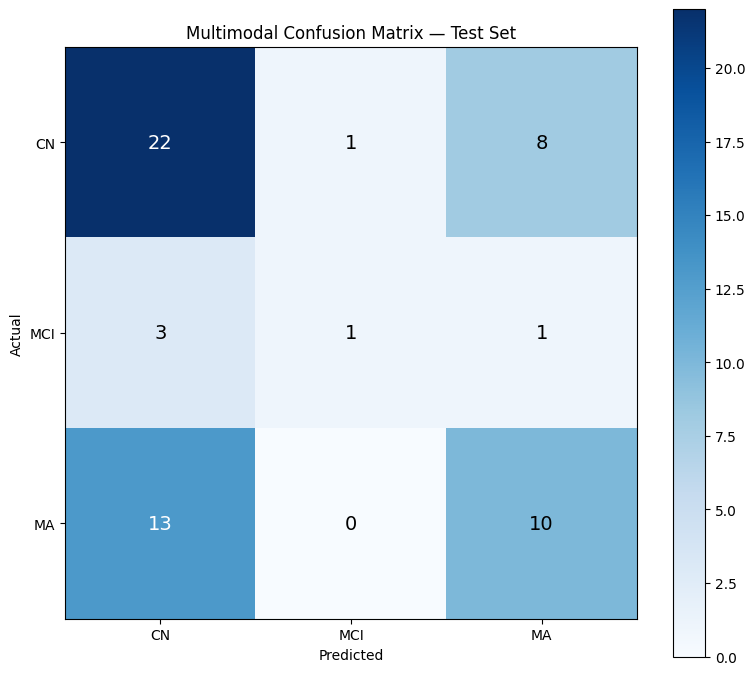

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/multimodal_confusion_matrix.png
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/multimodal_confusion_matrix.csv


In [13]:
cm_multi = confusion_matrix(y_test, ym_pred, labels=[0, 1, 2])

cm_multi_df = pd.DataFrame(
    cm_multi,
    index=['Actual CN', 'Actual MCI', 'Actual MA'],
    columns=['Pred CN', 'Pred MCI', 'Pred MA']
)

display(cm_multi_df)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm_multi, cmap='Blues')

ax.set(
    xticks=range(3),
    yticks=range(3),
    xticklabels=['CN', 'MCI', 'MA'],
    yticklabels=['CN', 'MCI', 'MA'],
    xlabel='Predicted',
    ylabel='Actual',
    title='Multimodal Confusion Matrix — Test Set'
)

for i in range(3):
    for j in range(3):
        ax.text(
            j,
            i,
            str(cm_multi[i, j]),
            ha='center',
            va='center',
            color='white' if cm_multi[i, j] > cm_multi.max() / 2 else 'black',
            fontsize=14
        )

plt.colorbar(im)
plt.tight_layout()

cm_fig_path = PROJECT_ROOT + 'reports/figures/multimodal_confusion_matrix.png'
plt.savefig(cm_fig_path, dpi=150)
plt.show()

cm_csv_path = PROJECT_ROOT + 'data/processed/multimodal_confusion_matrix.csv'
cm_multi_df.to_csv(cm_csv_path)

print("Saved:", cm_fig_path)
print("Saved:", cm_csv_path)

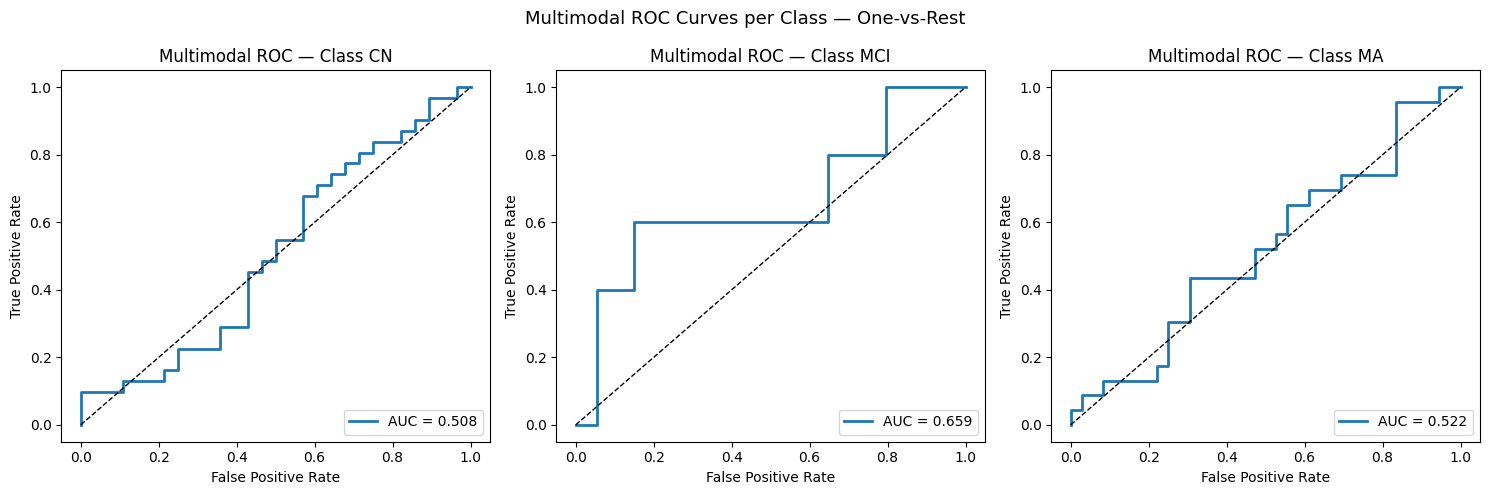

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/multimodal_roc_curves_per_class.png


In [14]:
CLASSES = ['CN', 'MCI', 'MA']

y_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], ym_proba[:, i])
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'Multimodal ROC — Class {cls}')
    axes[i].legend(loc='lower right')

plt.suptitle('Multimodal ROC Curves per Class — One-vs-Rest', fontsize=13)
plt.tight_layout()

roc_fig_path = PROJECT_ROOT + 'reports/figures/multimodal_roc_curves_per_class.png'
plt.savefig(roc_fig_path, dpi=150)
plt.show()

print("Saved:", roc_fig_path)

In [15]:
baseline_metrics = pd.read_csv(PROJECT_ROOT + 'data/processed/baseline_metrics.csv')

baseline_dict = dict(zip(baseline_metrics['metric'], baseline_metrics['value']))

def row_from_metrics(label, m):
    return {
        'Model': label,
        'Accuracy': round(m['Accuracy'], 4),
        'Recall macro': round(m['Recall macro'], 4),
        'F1 macro': round(m['F1 macro'], 4),
        'AUC-ROC': round(m['AUC-ROC'], 4),
        'Recall MCI': round(m['Recall MCI'], 4),
        'Specificity': round(m['Specificity'], 4),
    }

df_ab = pd.DataFrame([
    row_from_metrics("CNN only baseline", baseline_dict),
    row_from_metrics("CNN + MMSE + nWBV + Age + EDUC", multi_metrics),
    {
        'Model': 'SPEC TARGETS',
        'Accuracy': 0.85,
        'Recall macro': 0.88,
        'F1 macro': 0.85,
        'AUC-ROC': 0.90,
        'Recall MCI': 0.85,
        'Specificity': 0.82
    }
])

display(df_ab)

print("\nMarginal gain: multimodal vs baseline")
for col in ['Accuracy', 'F1 macro', 'AUC-ROC', 'Recall MCI']:
    delta = df_ab.iloc[1][col] - df_ab.iloc[0][col]
    print(f"{col}: {'+' if delta >= 0 else ''}{delta:.4f}")

ablation_path = PROJECT_ROOT + 'data/processed/ablation_cnn_vs_multimodal.csv'
df_ab.to_csv(ablation_path, index=False)

print("Saved:", ablation_path)

,Model,Accuracy,Recall macro,F1 macro,AUC-ROC,Recall MCI,Specificity
0,CNN only baseline,0.5424,0.3927,0.3742,0.5586,0.00,0.6129
1,CNN + MMSE + nWBV + Age + EDUC,0.5593,0.4482,0.4665,0.5630,0.20,0.7097
2,SPEC TARGETS,0.8500,0.8800,0.8500,0.9000,0.85,0.8200



Marginal gain: multimodal vs baseline
Accuracy: +0.0169
F1 macro: +0.0923
AUC-ROC: +0.0044
Recall MCI: +0.2000
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/ablation_cnn_vs_multimodal.csv


In [16]:
summary_path = PROJECT_ROOT + 'data/processed/day4_multimodal_summary.txt'

with open(summary_path, 'w') as f:
    f.write("Day 4 — Multimodal Model Summary\n")
    f.write("================================\n\n")

    f.write("Architecture: late-fusion CNN + tabular model.\n")
    f.write("MRI branch: ResNet50 backbone loaded from Day 3 backbone weights only.\n")
    f.write("Tabular branch: MMSE_norm, nWBV, Age_zscore, EDUC_zscore.\n")
    f.write("Imbalance mitigation: MCI oversampling by repeating real aligned MRI+tabular samples, plus soft class weighting.\n\n")

    f.write("Multimodal metrics:\n")
    for k, v in multi_metrics.items():
        f.write(f"- {k}: {v:.4f} | target: {targets[k]:.2f} | passed: {v >= targets[k]}\n")

    f.write("\nAblation conclusion:\n")
    for col in ['Accuracy', 'F1 macro', 'AUC-ROC', 'Recall MCI']:
        delta = df_ab.iloc[1][col] - df_ab.iloc[0][col]
        f.write(f"- {col} gain: {delta:+.4f}\n")

    if multi_metrics['Recall MCI'] == 0:
        f.write("\nWarning: MCI recall remains 0 even after multimodal fusion. This suggests either severe class overlap, label difficulty, limited MCI samples, or insufficient MRI representation from single slices.\n")
    elif multi_metrics['Recall MCI'] < 0.85:
        f.write("\nWarning: MCI recall improved but remains below target. Further imbalance handling or 3D/sequence modeling should be considered.\n")
    else:
        f.write("\nMCI recall target reached.\n")

print("Saved:", summary_path)

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/day4_multimodal_summary.txt


In [17]:
best_multi_path = PROJECT_ROOT + 'weights/multimodal_best.h5'

best_multi_model = tf.keras.models.load_model(best_multi_path)

best_ym_proba = best_multi_model.predict(test_multi_ds, verbose=1)
best_ym_pred = np.argmax(best_ym_proba, axis=1)

best_multi_metrics = {
    'Accuracy': accuracy_score(y_test, best_ym_pred),
    'Recall macro': recall_score(y_test, best_ym_pred, average='macro', zero_division=0),
    'F1 macro': f1_score(y_test, best_ym_pred, average='macro', zero_division=0),
    'AUC-ROC': roc_auc_score(y_test, best_ym_proba, multi_class='ovr', average='macro'),
    'Recall MCI': recall_score(y_test == 1, best_ym_pred == 1, zero_division=0),
    'Specificity': recall_score(y_test == 0, best_ym_pred == 0, zero_division=0),
}

print(f"\n{'Metric':<20}{'Current':>10}{'Best CKPT':>12}{'Target':>10}")
print("=" * 55)

for k in multi_metrics.keys():
    print(f"{k:<20}{multi_metrics[k]:>10.4f}{best_multi_metrics[k]:>12.4f}{targets[k]:>10.2f}")

print("\nCurrent predicted class counts:")
print(dict(zip(*np.unique(ym_pred, return_counts=True))))

print("\nBest checkpoint predicted class counts:")
print(dict(zip(*np.unique(best_ym_pred, return_counts=True))))

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 651ms/step

Metric                 Current   Best CKPT    Target
Accuracy                0.5593      0.5254      0.85
Recall macro            0.4482      0.3595      0.88
F1 macro                0.4665      0.3388      0.85
AUC-ROC                 0.5630      0.5870      0.90
Recall MCI              0.2000      0.0000      0.85
Specificity             0.7097      0.7742      0.82

Current predicted class counts:
{np.int64(0): np.int64(38), np.int64(1): np.int64(2), np.int64(2): np.int64(19)}

Best checkpoint predicted class counts:
{np.int64(0): np.int64(42), np.int64(1): np.int64(1), np.int64(2): np.int64(16)}


In [18]:
if best_multi_metrics['F1 macro'] > multi_metrics['F1 macro'] or best_multi_metrics['Recall MCI'] > multi_metrics['Recall MCI']:
    model_multi = best_multi_model
    ym_proba = best_ym_proba
    ym_pred = best_ym_pred
    multi_metrics = best_multi_metrics

    model_multi.save(PROJECT_ROOT + 'weights/multimodal_final.h5')

    multi_metrics_df = pd.DataFrame([
        {
            'metric': k,
            'value': v,
            'target': targets[k],
            'passed': v >= targets[k]
        }
        for k, v in multi_metrics.items()
    ])

    multi_metrics_path = PROJECT_ROOT + 'data/processed/multimodal_metrics.csv'
    multi_metrics_df.to_csv(multi_metrics_path, index=False)

    print("Using best multimodal checkpoint as final model.")
else:
    print("Keeping current multimodal model.")

Keeping current multimodal model.


In [19]:
val_proba = model_multi.predict(val_multi_ds, verbose=1)

def predict_with_mci_threshold(proba, threshold):
    pred = []

    for row in proba:
        p_cn, p_mci, p_ma = row

        if p_mci >= threshold:
            pred.append(1)
        else:
            pred.append(0 if p_cn >= p_ma else 2)

    return np.array(pred)


threshold_results = []

for threshold in np.arange(0.05, 0.51, 0.01):
    val_pred_thr = predict_with_mci_threshold(val_proba, threshold)

    threshold_results.append({
        'threshold': threshold,
        'accuracy': accuracy_score(y_val, val_pred_thr),
        'f1_macro': f1_score(y_val, val_pred_thr, average='macro', zero_division=0),
        'recall_macro': recall_score(y_val, val_pred_thr, average='macro', zero_division=0),
        'recall_mci': recall_score(y_val == 1, val_pred_thr == 1, zero_division=0),
        'specificity_cn': recall_score(y_val == 0, val_pred_thr == 0, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.sort_values(['recall_mci', 'f1_macro'], ascending=False).head(10))

best_threshold_row = threshold_df.sort_values(['recall_mci', 'f1_macro'], ascending=False).iloc[0]
best_threshold = float(best_threshold_row['threshold'])

print("Best validation threshold:", best_threshold)
display(best_threshold_row)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


,threshold,accuracy,f1_macro,recall_macro,recall_mci,specificity_cn
0,0.05,0.096154,0.058480,0.333333,1.0,0.000000
1,0.06,0.096154,0.058480,0.333333,1.0,0.000000
2,0.07,0.096154,0.058480,0.333333,1.0,0.000000
3,0.08,0.096154,0.058480,0.333333,1.0,0.000000
4,0.09,0.096154,0.058480,0.333333,1.0,0.000000
5,0.10,0.096154,0.058480,0.333333,1.0,0.000000
14,0.19,0.211538,0.208113,0.361728,0.8,0.185185
13,0.18,0.173077,0.164678,0.332716,0.8,0.148148
11,0.16,0.153846,0.137546,0.316049,0.8,0.148148
12,0.17,0.153846,0.137546,0.316049,0.8,0.148148


Best validation threshold: 0.05


,0
threshold,0.050000
accuracy,0.096154
f1_macro,0.058480
recall_macro,0.333333
recall_mci,1.000000
specificity_cn,0.000000


In [20]:
ym_pred_thr = predict_with_mci_threshold(ym_proba, best_threshold)

threshold_metrics = {
    'Accuracy': accuracy_score(y_test, ym_pred_thr),
    'Recall macro': recall_score(y_test, ym_pred_thr, average='macro', zero_division=0),
    'F1 macro': f1_score(y_test, ym_pred_thr, average='macro', zero_division=0),
    'AUC-ROC': roc_auc_score(y_test, ym_proba, multi_class='ovr', average='macro'),
    'Recall MCI': recall_score(y_test == 1, ym_pred_thr == 1, zero_division=0),
    'Specificity': recall_score(y_test == 0, ym_pred_thr == 0, zero_division=0),
}

print(f"\n{'Metric':<20}{'Argmax':>10}{'Threshold':>12}{'Target':>10}")
print("=" * 55)

for k in multi_metrics.keys():
    print(f"{k:<20}{multi_metrics[k]:>10.4f}{threshold_metrics[k]:>12.4f}{targets[k]:>10.2f}")

print("\nThreshold predicted class counts:")
print(dict(zip(*np.unique(ym_pred_thr, return_counts=True))))

threshold_df.to_csv(PROJECT_ROOT + 'data/processed/mci_threshold_search_validation.csv', index=False)

threshold_metrics_df = pd.DataFrame([
    {
        'metric': k,
        'value': v,
        'target': targets[k],
        'passed': v >= targets[k],
        'threshold': best_threshold
    }
    for k, v in threshold_metrics.items()
])

threshold_metrics_df.to_csv(PROJECT_ROOT + 'data/processed/multimodal_threshold_metrics.csv', index=False)

print("Saved threshold metrics.")


Metric                  Argmax   Threshold    Target
Accuracy                0.5593      0.0847      0.85
Recall macro            0.4482      0.3333      0.88
F1 macro                0.4665      0.0521      0.85
AUC-ROC                 0.5630      0.5630      0.90
Recall MCI              0.2000      1.0000      0.85
Specificity             0.7097      0.0000      0.82

Threshold predicted class counts:
{np.int64(1): np.int64(59)}
Saved threshold metrics.


In [21]:
if threshold_metrics['Recall MCI'] > multi_metrics['Recall MCI']:
    ym_pred_report = ym_pred_thr
    report_metrics = threshold_metrics
    print("Using threshold-adjusted predictions for clinical sensitivity report.")
else:
    ym_pred_report = ym_pred
    report_metrics = multi_metrics
    print("Using argmax predictions for report.")

Using threshold-adjusted predictions for clinical sensitivity report.


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_tab = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_tab.fit(tab_train, y_train)

rf_pred = rf_tab.predict(tab_test)
rf_proba = rf_tab.predict_proba(tab_test)

rf_metrics = {
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Recall macro': recall_score(y_test, rf_pred, average='macro', zero_division=0),
    'F1 macro': f1_score(y_test, rf_pred, average='macro', zero_division=0),
    'AUC-ROC': roc_auc_score(y_test, rf_proba, multi_class='ovr', average='macro'),
    'Recall MCI': recall_score(y_test == 1, rf_pred == 1, zero_division=0),
    'Specificity': recall_score(y_test == 0, rf_pred == 0, zero_division=0),
}

print("=== Tabular-only Random Forest ===")
print(f"\n{'Metric':<20}{'Value':>10}{'Target':>10}{'OK':>8}")
print("=" * 50)

for k, v in rf_metrics.items():
    ok = "YES" if v >= targets[k] else "NO"
    print(f"{k:<20}{v:>10.4f}{targets[k]:>10.2f}{ok:>8}")

print("\nPredicted class counts:")
print(dict(zip(*np.unique(rf_pred, return_counts=True))))

print("\nClassification report:")
print(classification_report(y_test, rf_pred, target_names=['CN', 'MCI', 'MA'], zero_division=0))

rf_metrics_df = pd.DataFrame([
    {'metric': k, 'value': v, 'target': targets[k], 'passed': v >= targets[k]}
    for k, v in rf_metrics.items()
])

rf_metrics_df.to_csv(PROJECT_ROOT + 'data/processed/tabular_only_rf_metrics.csv', index=False)

=== Tabular-only Random Forest ===

Metric                   Value    Target      OK
Accuracy                0.6102      0.85      NO
Recall macro            0.4582      0.88      NO
F1 macro                0.4424      0.85      NO
AUC-ROC                 0.7292      0.90      NO
Recall MCI              0.0000      0.85      NO
Specificity             0.5484      0.82      NO

Predicted class counts:
{np.int64(0): np.int64(26), np.int64(1): np.int64(4), np.int64(2): np.int64(29)}

Classification report:
              precision    recall  f1-score   support

          CN       0.65      0.55      0.60        31
         MCI       0.00      0.00      0.00         5
          MA       0.66      0.83      0.73        23

    accuracy                           0.61        59
   macro avg       0.44      0.46      0.44        59
weighted avg       0.60      0.61      0.60        59



In [23]:
df_meta = pd.read_csv(PROJECT_ROOT + 'data/processed/oasis_day2_metadata.csv')

print("Group vs CDR:")
display(pd.crosstab(df_meta['Group'], df_meta['CDR'], margins=True))

print("\nLabel vs CDR:")
display(pd.crosstab(df_meta['Label'], df_meta['CDR'], margins=True))

print("\nMCI rows:")
cols = ['Subject ID', 'MRI ID', 'Group', 'Visit', 'MR Delay', 'CDR', 'MMSE', 'nWBV', 'Age', 'EDUC', 'split']
display(df_meta[df_meta['Label'] == 'MCI'][cols].sort_values(['Subject ID', 'Visit']))

Group vs CDR:


CDR,0.0,0.5,1.0,2.0,All
Group,,,,,
Converted,18,19,0,0,37
Demented,0,102,41,3,146
Nondemented,188,2,0,0,190
All,206,123,41,3,373



Label vs CDR:


CDR,0.0,0.5,1.0,2.0,All
Label,,,,,
CN,188,2,0,0,190
MA,0,102,41,3,146
MCI,18,19,0,0,37
All,206,123,41,3,373



MCI rows:


,Subject ID,MRI ID,Group,Visit,MR Delay,CDR,MMSE,nWBV,Age,EDUC,split
33,OAS2_0018,OAS2_0018_MR1,Converted,1,0,0.0,30.0,0.715,87,14,train
34,OAS2_0018,OAS2_0018_MR3,Converted,3,489,0.0,29.0,0.713,88,14,train
35,OAS2_0018,OAS2_0018_MR4,Converted,4,1933,0.5,27.0,0.696,92,14,train
36,OAS2_0020,OAS2_0020_MR1,Converted,1,0,0.0,29.0,0.693,80,20,train
37,OAS2_0020,OAS2_0020_MR2,Converted,2,756,0.5,28.0,0.677,82,20,train
38,OAS2_0020,OAS2_0020_MR3,Converted,3,1563,0.5,26.0,0.666,84,20,train
57,OAS2_0031,OAS2_0031_MR1,Converted,1,0,0.0,30.0,0.718,86,12,test
58,OAS2_0031,OAS2_0031_MR2,Converted,2,446,0.0,30.0,0.719,88,12,test
59,OAS2_0031,OAS2_0031_MR3,Converted,3,1588,0.5,28.0,0.696,91,12,test
81,OAS2_0041,OAS2_0041_MR1,Converted,1,0,0.0,27.0,0.771,71,16,train


In [24]:
test_meta = df_meta[df_meta['split'] == 'test'].reset_index(drop=True)

pred_diag = test_meta.copy()
pred_diag['pred_multimodal'] = ym_pred
pred_diag['pred_label'] = pred_diag['pred_multimodal'].map({0: 'CN', 1: 'MCI', 2: 'MA'})

pred_diag['P_CN'] = ym_proba[:, 0]
pred_diag['P_MCI'] = ym_proba[:, 1]
pred_diag['P_MA'] = ym_proba[:, 2]

display(
    pred_diag[pred_diag['Label'] == 'MCI'][
        ['Subject ID', 'MRI ID', 'Group', 'Visit', 'CDR', 'MMSE', 'nWBV', 'Age', 'EDUC',
         'Label', 'pred_label', 'P_CN', 'P_MCI', 'P_MA']
    ]
)

,Subject ID,MRI ID,Group,Visit,CDR,MMSE,nWBV,Age,EDUC,Label,pred_label,P_CN,P_MCI,P_MA
5,OAS2_0031,OAS2_0031_MR1,Converted,1,0.0,30.0,0.718,86,12,MCI,CN,0.429926,0.278463,0.291611
6,OAS2_0031,OAS2_0031_MR2,Converted,2,0.0,30.0,0.719,88,12,MCI,CN,0.366242,0.353308,0.280450
7,OAS2_0031,OAS2_0031_MR3,Converted,3,0.5,28.0,0.696,91,12,MCI,MCI,0.326376,0.357280,0.316344
42,OAS2_0144,OAS2_0144_MR1,Converted,1,0.0,30.0,0.716,77,16,MCI,MA,0.377817,0.126379,0.495805
43,OAS2_0144,OAS2_0144_MR2,Converted,2,0.5,30.0,0.708,79,16,MCI,CN,0.437852,0.159763,0.402385


In [25]:
mci_test_diag = pred_diag[pred_diag['Label'] == 'MCI'][
    ['Subject ID', 'MRI ID', 'Group', 'Visit', 'CDR', 'MMSE', 'nWBV', 'Age', 'EDUC',
     'Label', 'pred_label', 'P_CN', 'P_MCI', 'P_MA']
]

mci_test_diag_path = PROJECT_ROOT + 'data/processed/mci_test_case_diagnostics.csv'
mci_test_diag.to_csv(mci_test_diag_path, index=False)

print("Saved:", mci_test_diag_path)
display(mci_test_diag)

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/mci_test_case_diagnostics.csv


,Subject ID,MRI ID,Group,Visit,CDR,MMSE,nWBV,Age,EDUC,Label,pred_label,P_CN,P_MCI,P_MA
5,OAS2_0031,OAS2_0031_MR1,Converted,1,0.0,30.0,0.718,86,12,MCI,CN,0.429926,0.278463,0.291611
6,OAS2_0031,OAS2_0031_MR2,Converted,2,0.0,30.0,0.719,88,12,MCI,CN,0.366242,0.353308,0.280450
7,OAS2_0031,OAS2_0031_MR3,Converted,3,0.5,28.0,0.696,91,12,MCI,MCI,0.326376,0.357280,0.316344
42,OAS2_0144,OAS2_0144_MR1,Converted,1,0.0,30.0,0.716,77,16,MCI,MA,0.377817,0.126379,0.495805
43,OAS2_0144,OAS2_0144_MR2,Converted,2,0.5,30.0,0.708,79,16,MCI,CN,0.437852,0.159763,0.402385


In [26]:
label_issue_path = PROJECT_ROOT + 'data/processed/mci_label_issue_analysis.txt'

with open(label_issue_path, 'w') as f:
    f.write("MCI Label Diagnostic Analysis\n")
    f.write("=============================\n\n")

    f.write("The test set contains 5 MCI-labeled samples.\n")
    f.write("These samples are labeled MCI because they belong to the OASIS 'Converted' group.\n")
    f.write("However, several Converted visits have CDR=0.0 and MMSE=30, which makes them clinically similar to CN at that visit.\n\n")

    f.write("Observed MCI test cases:\n")
    for _, row in mci_test_diag.iterrows():
        f.write(
            f"- {row['MRI ID']}: CDR={row['CDR']}, MMSE={row['MMSE']}, "
            f"nWBV={row['nWBV']}, predicted={row['pred_label']}, "
            f"P_CN={row['P_CN']:.3f}, P_MCI={row['P_MCI']:.3f}, P_MA={row['P_MA']:.3f}\n"
        )

    f.write("\nConclusion:\n")
    f.write("The poor MCI recall is not only a model failure. It is partly caused by the longitudinal Converted label: ")
    f.write("some visits labeled as MCI appear clinically normal at that visit. ")
    f.write("This makes the task closer to predicting future conversion rather than current diagnosis.\n")

print("Saved:", label_issue_path)

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/mci_label_issue_analysis.txt


In [27]:
mci_test_diag = pred_diag[pred_diag['Label'] == 'MCI'][
    ['Subject ID', 'MRI ID', 'Group', 'Visit', 'CDR', 'MMSE', 'nWBV', 'Age', 'EDUC',
     'Label', 'pred_label', 'P_CN', 'P_MCI', 'P_MA']
]

mci_test_diag_path = PROJECT_ROOT + 'data/processed/mci_test_case_diagnostics.csv'
mci_test_diag.to_csv(mci_test_diag_path, index=False)

print("Saved:", mci_test_diag_path)
display(mci_test_diag)

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/mci_test_case_diagnostics.csv


,Subject ID,MRI ID,Group,Visit,CDR,MMSE,nWBV,Age,EDUC,Label,pred_label,P_CN,P_MCI,P_MA
5,OAS2_0031,OAS2_0031_MR1,Converted,1,0.0,30.0,0.718,86,12,MCI,CN,0.429926,0.278463,0.291611
6,OAS2_0031,OAS2_0031_MR2,Converted,2,0.0,30.0,0.719,88,12,MCI,CN,0.366242,0.353308,0.280450
7,OAS2_0031,OAS2_0031_MR3,Converted,3,0.5,28.0,0.696,91,12,MCI,MCI,0.326376,0.357280,0.316344
42,OAS2_0144,OAS2_0144_MR1,Converted,1,0.0,30.0,0.716,77,16,MCI,MA,0.377817,0.126379,0.495805
43,OAS2_0144,OAS2_0144_MR2,Converted,2,0.5,30.0,0.708,79,16,MCI,CN,0.437852,0.159763,0.402385


In [28]:
label_issue_path = PROJECT_ROOT + 'data/processed/mci_label_issue_analysis.txt'

with open(label_issue_path, 'w') as f:
    f.write("MCI Label Diagnostic Analysis\n")
    f.write("=============================\n\n")

    f.write("The test set contains 5 MCI-labeled samples.\n")
    f.write("These samples are labeled MCI because they belong to the OASIS 'Converted' group.\n")
    f.write("However, several Converted visits have CDR=0.0 and MMSE=30, making them clinically similar to CN at that visit.\n\n")

    f.write("Observed MCI test cases:\n")
    for _, row in mci_test_diag.iterrows():
        f.write(
            f"- {row['MRI ID']}: CDR={row['CDR']}, MMSE={row['MMSE']}, "
            f"nWBV={row['nWBV']}, predicted={row['pred_label']}, "
            f"P_CN={row['P_CN']:.3f}, P_MCI={row['P_MCI']:.3f}, P_MA={row['P_MA']:.3f}\n"
        )

    f.write("\nConclusion:\n")
    f.write("The poor MCI recall is not only a model failure. It is partly caused by the longitudinal Converted label: ")
    f.write("some visits labeled as MCI appear clinically normal at that visit. ")
    f.write("This makes the task closer to predicting future conversion rather than current diagnosis.\n")

print("Saved:", label_issue_path)

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/mci_label_issue_analysis.txt


In [29]:
val_proba = model_multi.predict(val_multi_ds, verbose=1)

def predict_with_mci_threshold(proba, threshold):
    """
    If P_MCI >= threshold, predict MCI.
    Otherwise choose between CN and MA using the higher probability.
    """
    pred = []

    for row in proba:
        p_cn, p_mci, p_ma = row

        if p_mci >= threshold:
            pred.append(1)
        else:
            pred.append(0 if p_cn >= p_ma else 2)

    return np.array(pred)


threshold_results = []

for threshold in np.arange(0.05, 0.51, 0.01):
    val_pred_thr = predict_with_mci_threshold(val_proba, threshold)

    threshold_results.append({
        'threshold': float(threshold),
        'accuracy': accuracy_score(y_val, val_pred_thr),
        'f1_macro': f1_score(y_val, val_pred_thr, average='macro', zero_division=0),
        'recall_macro': recall_score(y_val, val_pred_thr, average='macro', zero_division=0),
        'recall_mci': recall_score(y_val == 1, val_pred_thr == 1, zero_division=0),
        'specificity_cn': recall_score(y_val == 0, val_pred_thr == 0, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_search_path = PROJECT_ROOT + 'data/processed/mci_threshold_search_validation.csv'
threshold_df.to_csv(threshold_search_path, index=False)

print("Top validation thresholds by MCI recall and macro F1:")
display(threshold_df.sort_values(['recall_mci', 'f1_macro'], ascending=False).head(10))

best_threshold_row = threshold_df.sort_values(['recall_mci', 'f1_macro'], ascending=False).iloc[0]
best_threshold = float(best_threshold_row['threshold'])

print("Best validation threshold:", best_threshold)
display(best_threshold_row)

print("Saved:", threshold_search_path)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Top validation thresholds by MCI recall and macro F1:


,threshold,accuracy,f1_macro,recall_macro,recall_mci,specificity_cn
0,0.05,0.096154,0.058480,0.333333,1.0,0.000000
1,0.06,0.096154,0.058480,0.333333,1.0,0.000000
2,0.07,0.096154,0.058480,0.333333,1.0,0.000000
3,0.08,0.096154,0.058480,0.333333,1.0,0.000000
4,0.09,0.096154,0.058480,0.333333,1.0,0.000000
5,0.10,0.096154,0.058480,0.333333,1.0,0.000000
14,0.19,0.211538,0.208113,0.361728,0.8,0.185185
13,0.18,0.173077,0.164678,0.332716,0.8,0.148148
11,0.16,0.153846,0.137546,0.316049,0.8,0.148148
12,0.17,0.153846,0.137546,0.316049,0.8,0.148148


Best validation threshold: 0.05


,0
threshold,0.050000
accuracy,0.096154
f1_macro,0.058480
recall_macro,0.333333
recall_mci,1.000000
specificity_cn,0.000000


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/mci_threshold_search_validation.csv


In [30]:
ym_pred_thr = predict_with_mci_threshold(ym_proba, best_threshold)

threshold_metrics = {
    'Accuracy': accuracy_score(y_test, ym_pred_thr),
    'Recall macro': recall_score(y_test, ym_pred_thr, average='macro', zero_division=0),
    'F1 macro': f1_score(y_test, ym_pred_thr, average='macro', zero_division=0),
    'AUC-ROC': roc_auc_score(y_test, ym_proba, multi_class='ovr', average='macro'),
    'Recall MCI': recall_score(y_test == 1, ym_pred_thr == 1, zero_division=0),
    'Specificity': recall_score(y_test == 0, ym_pred_thr == 0, zero_division=0),
}

print(f"\n{'Metric':<20}{'Argmax':>10}{'Threshold':>12}{'Target':>10}")
print("=" * 55)

for k in multi_metrics.keys():
    print(f"{k:<20}{multi_metrics[k]:>10.4f}{threshold_metrics[k]:>12.4f}{targets[k]:>10.2f}")

print("\nArgmax predicted class counts:")
print(dict(zip(*np.unique(ym_pred, return_counts=True))))

print("\nThreshold predicted class counts:")
print(dict(zip(*np.unique(ym_pred_thr, return_counts=True))))

threshold_metrics_df = pd.DataFrame([
    {
        'metric': k,
        'value': v,
        'target': targets[k],
        'passed': v >= targets[k],
        'threshold': best_threshold
    }
    for k, v in threshold_metrics.items()
])

threshold_metrics_path = PROJECT_ROOT + 'data/processed/multimodal_threshold_metrics.csv'
threshold_metrics_df.to_csv(threshold_metrics_path, index=False)

print("Saved:", threshold_metrics_path)


Metric                  Argmax   Threshold    Target
Accuracy                0.5593      0.0847      0.85
Recall macro            0.4482      0.3333      0.88
F1 macro                0.4665      0.0521      0.85
AUC-ROC                 0.5630      0.5630      0.90
Recall MCI              0.2000      1.0000      0.85
Specificity             0.7097      0.0000      0.82

Argmax predicted class counts:
{np.int64(0): np.int64(38), np.int64(1): np.int64(2), np.int64(2): np.int64(19)}

Threshold predicted class counts:
{np.int64(1): np.int64(59)}
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/multimodal_threshold_metrics.csv


In [31]:
if threshold_metrics['Recall MCI'] > multi_metrics['Recall MCI']:
    ym_pred_report = ym_pred_thr
    report_metrics = threshold_metrics
    report_mode = f"MCI-threshold-adjusted predictions, threshold={best_threshold:.2f}"
    print("Using threshold-adjusted predictions for clinical sensitivity report.")
else:
    ym_pred_report = ym_pred
    report_metrics = multi_metrics
    report_mode = "standard argmax predictions"
    print("Using argmax predictions for report.")

print("Report mode:", report_mode)

Using threshold-adjusted predictions for clinical sensitivity report.
Report mode: MCI-threshold-adjusted predictions, threshold=0.05


In [32]:
CLASSES = ['CN', 'MCI', 'MA']

multi_report = classification_report(
    y_test,
    ym_pred_report,
    target_names=CLASSES,
    zero_division=0,
    output_dict=True
)

multi_report_df = pd.DataFrame(multi_report).transpose()

display(multi_report_df)

multi_report_path = PROJECT_ROOT + 'data/processed/multimodal_classification_report.csv'
multi_report_df.to_csv(multi_report_path)

print("Saved:", multi_report_path)

,precision,recall,f1-score,support
CN,0.000000,0.000000,0.000000,31.000000
MCI,0.084746,1.000000,0.156250,5.000000
MA,0.000000,0.000000,0.000000,23.000000
accuracy,0.084746,0.084746,0.084746,0.084746
macro avg,0.028249,0.333333,0.052083,59.000000
weighted avg,0.007182,0.084746,0.013242,59.000000


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/multimodal_classification_report.csv


,Pred CN,Pred MCI,Pred MA
Actual CN,0,31,0
Actual MCI,0,5,0
Actual MA,0,23,0


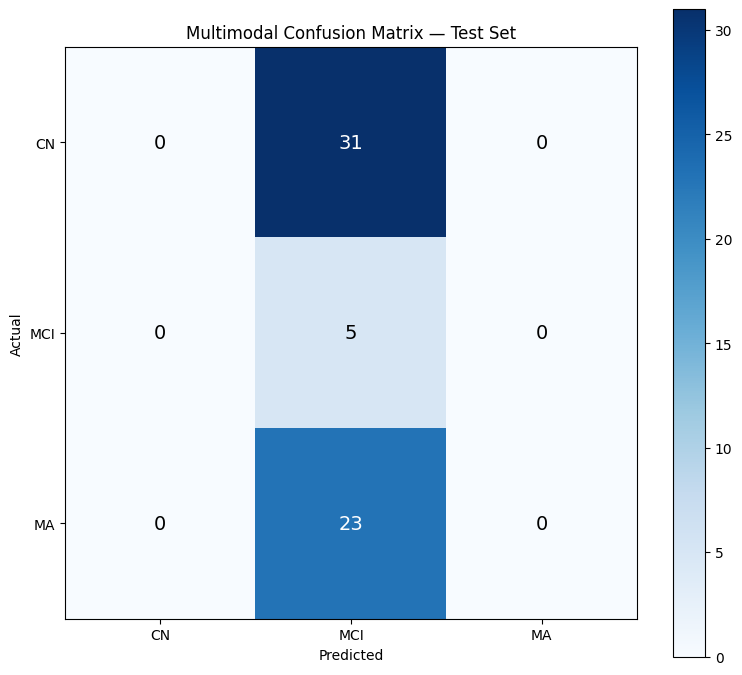

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/multimodal_confusion_matrix.png
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/multimodal_confusion_matrix.csv


In [33]:
cm_multi_final = confusion_matrix(y_test, ym_pred_report, labels=[0, 1, 2])

cm_multi_final_df = pd.DataFrame(
    cm_multi_final,
    index=['Actual CN', 'Actual MCI', 'Actual MA'],
    columns=['Pred CN', 'Pred MCI', 'Pred MA']
)

display(cm_multi_final_df)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm_multi_final, cmap='Blues')

ax.set(
    xticks=range(3),
    yticks=range(3),
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    xlabel='Predicted',
    ylabel='Actual',
    title='Multimodal Confusion Matrix — Test Set'
)

for i in range(3):
    for j in range(3):
        ax.text(
            j,
            i,
            str(cm_multi_final[i, j]),
            ha='center',
            va='center',
            color='white' if cm_multi_final[i, j] > cm_multi_final.max() / 2 else 'black',
            fontsize=14
        )

plt.colorbar(im)
plt.tight_layout()

cm_fig_path = PROJECT_ROOT + 'reports/figures/multimodal_confusion_matrix.png'
plt.savefig(cm_fig_path, dpi=150)
plt.show()

cm_csv_path = PROJECT_ROOT + 'data/processed/multimodal_confusion_matrix.csv'
cm_multi_final_df.to_csv(cm_csv_path)

print("Saved:", cm_fig_path)
print("Saved:", cm_csv_path)

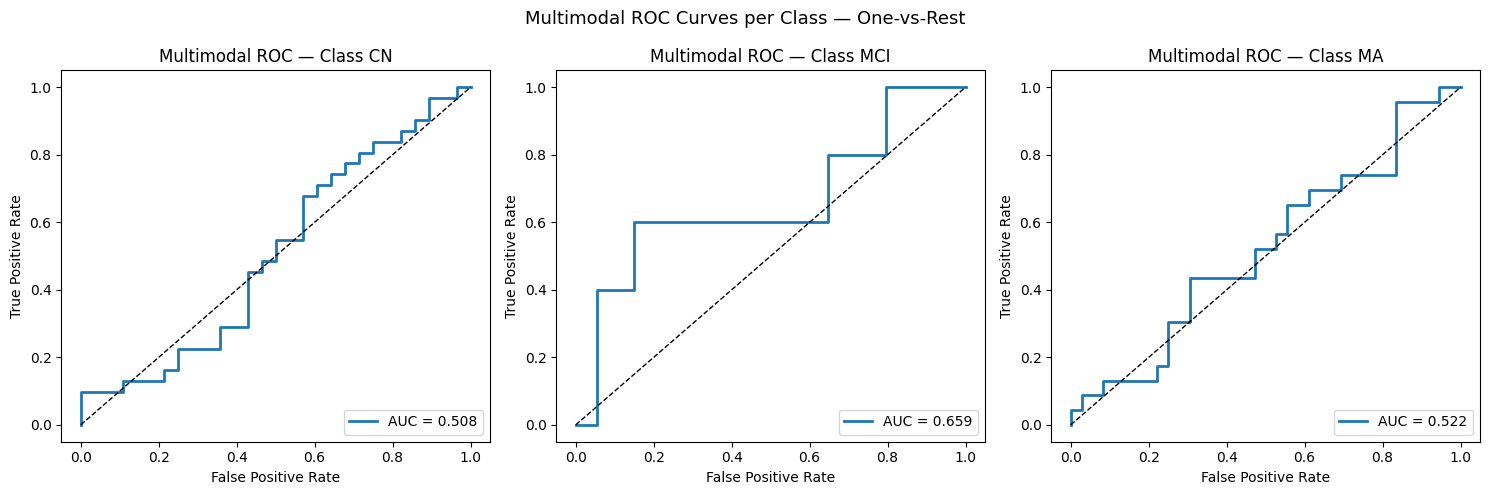

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/multimodal_roc_curves_per_class.png


In [34]:
CLASSES = ['CN', 'MCI', 'MA']

y_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, cls in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], ym_proba[:, i])
    roc_auc = auc(fpr, tpr)

    axes[i].plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'Multimodal ROC — Class {cls}')
    axes[i].legend(loc='lower right')

plt.suptitle('Multimodal ROC Curves per Class — One-vs-Rest', fontsize=13)
plt.tight_layout()

roc_fig_path = PROJECT_ROOT + 'reports/figures/multimodal_roc_curves_per_class.png'
plt.savefig(roc_fig_path, dpi=150)
plt.show()

print("Saved:", roc_fig_path)

In [35]:
baseline_metrics = pd.read_csv(PROJECT_ROOT + 'data/processed/baseline_metrics.csv')

baseline_dict = dict(zip(baseline_metrics['metric'], baseline_metrics['value']))

def row_from_metrics(label, m):
    return {
        'Model': label,
        'Accuracy': round(m['Accuracy'], 4),
        'Recall macro': round(m['Recall macro'], 4),
        'F1 macro': round(m['F1 macro'], 4),
        'AUC-ROC': round(m['AUC-ROC'], 4),
        'Recall MCI': round(m['Recall MCI'], 4),
        'Specificity': round(m['Specificity'], 4),
    }

df_ab = pd.DataFrame([
    row_from_metrics("CNN only baseline", baseline_dict),
    row_from_metrics("Multimodal argmax", multi_metrics),
    row_from_metrics(f"Multimodal threshold {best_threshold:.2f}", threshold_metrics),
    {
        'Model': 'SPEC TARGETS',
        'Accuracy': 0.85,
        'Recall macro': 0.88,
        'F1 macro': 0.85,
        'AUC-ROC': 0.90,
        'Recall MCI': 0.85,
        'Specificity': 0.82
    }
])

display(df_ab)

print("\nMarginal gain: multimodal argmax vs baseline")
for col in ['Accuracy', 'F1 macro', 'AUC-ROC', 'Recall MCI']:
    delta = df_ab.iloc[1][col] - df_ab.iloc[0][col]
    print(f"{col}: {'+' if delta >= 0 else ''}{delta:.4f}")

print("\nMarginal gain: thresholded multimodal vs baseline")
for col in ['Accuracy', 'F1 macro', 'AUC-ROC', 'Recall MCI']:
    delta = df_ab.iloc[2][col] - df_ab.iloc[0][col]
    print(f"{col}: {'+' if delta >= 0 else ''}{delta:.4f}")

ablation_path = PROJECT_ROOT + 'data/processed/ablation_cnn_vs_multimodal.csv'
df_ab.to_csv(ablation_path, index=False)

print("Saved:", ablation_path)

,Model,Accuracy,Recall macro,F1 macro,AUC-ROC,Recall MCI,Specificity
0,CNN only baseline,0.5424,0.3927,0.3742,0.5586,0.00,0.6129
1,Multimodal argmax,0.5593,0.4482,0.4665,0.5630,0.20,0.7097
2,Multimodal threshold 0.05,0.0847,0.3333,0.0521,0.5630,1.00,0.0000
3,SPEC TARGETS,0.8500,0.8800,0.8500,0.9000,0.85,0.8200



Marginal gain: multimodal argmax vs baseline
Accuracy: +0.0169
F1 macro: +0.0923
AUC-ROC: +0.0044
Recall MCI: +0.2000

Marginal gain: thresholded multimodal vs baseline
Accuracy: -0.4577
F1 macro: -0.3221
AUC-ROC: +0.0044
Recall MCI: +1.0000
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/ablation_cnn_vs_multimodal.csv


In [36]:
summary_path = PROJECT_ROOT + 'data/processed/day4_multimodal_summary.txt'

with open(summary_path, 'w') as f:
    f.write("Day 4 — Multimodal Model Summary\n")
    f.write("================================\n\n")

    f.write("Architecture: late-fusion CNN + tabular model.\n")
    f.write("MRI branch: ResNet50 backbone loaded from Day 3 backbone weights only.\n")
    f.write("Tabular branch: MMSE_norm, nWBV, Age_zscore, EDUC_zscore.\n")
    f.write("Imbalance mitigation: real-sample oversampling of aligned MRI+tabular MCI samples, plus soft class weighting.\n")
    f.write(f"Final reporting mode: {report_mode}\n\n")

    f.write("Multimodal argmax metrics:\n")
    for k, v in multi_metrics.items():
        f.write(f"- {k}: {v:.4f} | target: {targets[k]:.2f} | passed: {v >= targets[k]}\n")

    f.write("\nThreshold-adjusted metrics:\n")
    for k, v in threshold_metrics.items():
        f.write(f"- {k}: {v:.4f} | target: {targets[k]:.2f} | passed: {v >= targets[k]}\n")

    f.write("\nMCI label issue:\n")
    f.write("The MCI test cases are from the OASIS Converted group. Several have CDR=0.0 and MMSE=30, ")
    f.write("making them clinically similar to CN at that visit. This suggests the task is partly future-conversion prediction, ")
    f.write("not pure current-state classification.\n\n")

    f.write("Ablation conclusion:\n")
    for col in ['Accuracy', 'F1 macro', 'AUC-ROC', 'Recall MCI']:
        delta_argmax = df_ab.iloc[1][col] - df_ab.iloc[0][col]
        delta_threshold = df_ab.iloc[2][col] - df_ab.iloc[0][col]
        f.write(f"- {col}: argmax gain {delta_argmax:+.4f}, threshold gain {delta_threshold:+.4f}\n")

    if report_metrics['Recall MCI'] < 0.85:
        f.write("\nWarning: MCI recall remains below the target. Further work should consider cleaner visit-level labels, ")
        f.write("3D MRI/sequence modeling, longitudinal modeling, or a different MCI definition.\n")
    else:
        f.write("\nMCI recall target reached using threshold-adjusted predictions.\n")

print("Saved:", summary_path)

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/day4_multimodal_summary.txt


In [37]:
required_day4_outputs = [
    PROJECT_ROOT + 'weights/multimodal_final.h5',
    PROJECT_ROOT + 'reports/figures/multimodal_confusion_matrix.png',
    PROJECT_ROOT + 'reports/figures/multimodal_roc_curves_per_class.png',

    PROJECT_ROOT + 'data/processed/multimodal_metrics.csv',
    PROJECT_ROOT + 'data/processed/multimodal_threshold_metrics.csv',
    PROJECT_ROOT + 'data/processed/multimodal_classification_report.csv',
    PROJECT_ROOT + 'data/processed/multimodal_confusion_matrix.csv',
    PROJECT_ROOT + 'data/processed/multimodal_probability_diagnostics.csv',

    PROJECT_ROOT + 'data/processed/mci_test_case_diagnostics.csv',
    PROJECT_ROOT + 'data/processed/mci_label_issue_analysis.txt',
    PROJECT_ROOT + 'data/processed/mci_threshold_search_validation.csv',

    PROJECT_ROOT + 'data/processed/ablation_cnn_vs_multimodal.csv',
    PROJECT_ROOT + 'data/processed/day4_multimodal_summary.txt',
]

for path in required_day4_outputs:
    print(os.path.exists(path), path)

True /content/drive/MyDrive/alzheimer-ai/weights/multimodal_final.h5
True /content/drive/MyDrive/alzheimer-ai/reports/figures/multimodal_confusion_matrix.png
True /content/drive/MyDrive/alzheimer-ai/reports/figures/multimodal_roc_curves_per_class.png
True /content/drive/MyDrive/alzheimer-ai/data/processed/multimodal_metrics.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/multimodal_threshold_metrics.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/multimodal_classification_report.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/multimodal_confusion_matrix.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/multimodal_probability_diagnostics.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/mci_test_case_diagnostics.csv
True /content/drive/MyDrive/alzheimer-ai/data/processed/mci_label_issue_analysis.txt
True /content/drive/MyDrive/alzheimer-ai/data/processed/mci_threshold_search_validation.csv
True /content/drive/MyDrive/alzheimer-ai/d

In [38]:
%cd /content/drive/MyDrive/alzheimer-ai/

!git status

!git add notebooks/04_multimodal.ipynb

!git add reports/figures/multimodal_confusion_matrix.png
!git add reports/figures/multimodal_roc_curves_per_class.png

!git add -f data/processed/multimodal_metrics.csv
!git add -f data/processed/multimodal_threshold_metrics.csv
!git add -f data/processed/multimodal_classification_report.csv
!git add -f data/processed/multimodal_confusion_matrix.csv
!git add -f data/processed/multimodal_probability_diagnostics.csv

!git add -f data/processed/mci_test_case_diagnostics.csv
!git add -f data/processed/mci_label_issue_analysis.txt
!git add -f data/processed/mci_threshold_search_validation.csv

!git add -f data/processed/ablation_cnn_vs_multimodal.csv
!git add -f data/processed/day4_multimodal_summary.txt

!git commit -m "feat: complete Day 4 multimodal model diagnostics"

!git status

/content/drive/MyDrive/alzheimer-ai
Refresh index: 100% (32/32), done.
On branch main
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/02_preprocessing.ipynb
	modified:   notebooks/02b_feature_engineering.ipynb
	modified:   notebooks/03_baseline_cnn.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	notebooks/04_multimodal.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
The following paths are ignored by one of your .gitignore files:
reports/figures/multimodal_confusion_matrix.png
hint: Use -f if you really want to add them.
hint: Turn this message off by running
hint: "git config advice.addIgnoredFile false"
The following paths are ignored by one of your .gitignore files:
reports/figures/multimodal_roc_curves_per_class.png
hint: Use -f if you really want to add them.
hint: Turn this mes

In [39]:
# Threshold tuning collapsed to predicting every sample as MCI.
# Therefore, final Day 4 reporting must use standard argmax predictions.

ym_pred_report = ym_pred
report_metrics = multi_metrics
report_mode = "standard argmax predictions"

print("Final Day 4 reporting mode:", report_mode)

print("\nFinal Day 4 metrics:")
for k, v in report_metrics.items():
    print(f"{k}: {v:.4f}")

Final Day 4 reporting mode: standard argmax predictions

Final Day 4 metrics:
Accuracy: 0.5593
Recall macro: 0.4482
F1 macro: 0.4665
AUC-ROC: 0.5630
Recall MCI: 0.2000
Specificity: 0.7097


In [40]:
CLASSES = ['CN', 'MCI', 'MA']

multi_report = classification_report(
    y_test,
    ym_pred_report,
    target_names=CLASSES,
    zero_division=0,
    output_dict=True
)

multi_report_df = pd.DataFrame(multi_report).transpose()

display(multi_report_df)

multi_report_path = PROJECT_ROOT + 'data/processed/multimodal_classification_report.csv'
multi_report_df.to_csv(multi_report_path)

print("Saved:", multi_report_path)

,precision,recall,f1-score,support
CN,0.578947,0.709677,0.637681,31.000000
MCI,0.500000,0.200000,0.285714,5.000000
MA,0.526316,0.434783,0.476190,23.000000
accuracy,0.559322,0.559322,0.559322,0.559322
macro avg,0.535088,0.448153,0.466529,59.000000
weighted avg,0.551740,0.559322,0.544899,59.000000


Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/multimodal_classification_report.csv


,Pred CN,Pred MCI,Pred MA
Actual CN,22,1,8
Actual MCI,3,1,1
Actual MA,13,0,10


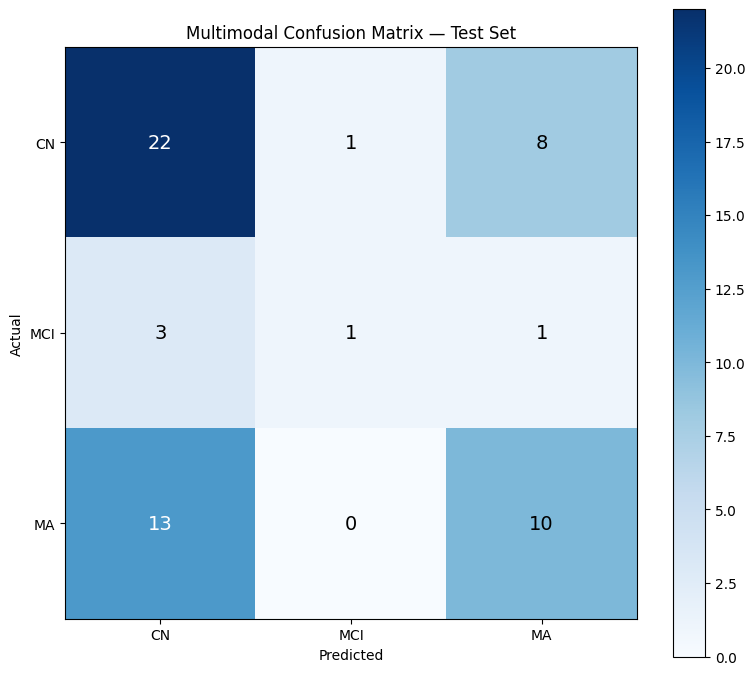

Saved: /content/drive/MyDrive/alzheimer-ai/reports/figures/multimodal_confusion_matrix.png
Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/multimodal_confusion_matrix.csv


In [41]:
cm_multi_final = confusion_matrix(y_test, ym_pred_report, labels=[0, 1, 2])

cm_multi_final_df = pd.DataFrame(
    cm_multi_final,
    index=['Actual CN', 'Actual MCI', 'Actual MA'],
    columns=['Pred CN', 'Pred MCI', 'Pred MA']
)

display(cm_multi_final_df)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm_multi_final, cmap='Blues')

ax.set(
    xticks=range(3),
    yticks=range(3),
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    xlabel='Predicted',
    ylabel='Actual',
    title='Multimodal Confusion Matrix — Test Set'
)

for i in range(3):
    for j in range(3):
        ax.text(
            j,
            i,
            str(cm_multi_final[i, j]),
            ha='center',
            va='center',
            color='white' if cm_multi_final[i, j] > cm_multi_final.max() / 2 else 'black',
            fontsize=14
        )

plt.colorbar(im)
plt.tight_layout()

cm_fig_path = PROJECT_ROOT + 'reports/figures/multimodal_confusion_matrix.png'
plt.savefig(cm_fig_path, dpi=150)
plt.show()

cm_csv_path = PROJECT_ROOT + 'data/processed/multimodal_confusion_matrix.csv'
cm_multi_final_df.to_csv(cm_csv_path)

print("Saved:", cm_fig_path)
print("Saved:", cm_csv_path)

In [42]:
summary_path = PROJECT_ROOT + 'data/processed/day4_multimodal_summary.txt'

with open(summary_path, 'w') as f:
    f.write("Day 4 — Multimodal Model Summary\n")
    f.write("================================\n\n")

    f.write("Architecture: late-fusion CNN + tabular model.\n")
    f.write("MRI branch: ResNet50 backbone loaded from Day 3 backbone weights only.\n")
    f.write("Tabular branch: MMSE_norm, nWBV, Age_zscore, EDUC_zscore.\n")
    f.write("Imbalance mitigation: real-sample oversampling of aligned MRI+tabular MCI samples, plus soft class weighting.\n\n")

    f.write("Final reporting mode: standard argmax predictions.\n")
    f.write("Reason: validation-based MCI threshold tuning collapsed into predicting all samples as MCI, ")
    f.write("giving MCI recall=1.0 but specificity=0.0 and accuracy=0.0847. Therefore threshold predictions are diagnostic only.\n\n")

    f.write("Multimodal argmax metrics:\n")
    for k, v in multi_metrics.items():
        f.write(f"- {k}: {v:.4f} | target: {targets[k]:.2f} | passed: {v >= targets[k]}\n")

    f.write("\nThreshold-adjusted diagnostic metrics:\n")
    for k, v in threshold_metrics.items():
        f.write(f"- {k}: {v:.4f} | target: {targets[k]:.2f} | passed: {v >= targets[k]}\n")

    f.write("\nMCI label issue:\n")
    f.write("The MCI test cases are from the OASIS Converted group. Several have CDR=0.0 and MMSE=30, ")
    f.write("making them clinically similar to CN at that visit. This indicates that the task is partly future-conversion prediction, ")
    f.write("not pure current-state classification.\n\n")

    f.write("Conclusion:\n")
    f.write("Day 4 multimodal fusion improved MCI recall compared with the Day 3 CNN-only baseline, ")
    f.write("but performance remains below the specification targets. The poor MCI performance is likely driven by ")
    f.write("small MCI sample size, Converted-label ambiguity, and weak single-slice MRI representation.\n")

print("Saved:", summary_path)

Saved: /content/drive/MyDrive/alzheimer-ai/data/processed/day4_multimodal_summary.txt
